In [25]:
from pydantic import BaseModel, Field

class Task(BaseModel):
    id: int = Field(..., description="The unique identifier of the task")
    title: str = Field(..., description="The title of the task")
    description: str = Field(..., description="A detailed description of the task")
    completed: bool = Field(False, description="Indicates whether the task is completed or not")

class Plan(BaseModel):
    title: str = Field(..., description="The title of the Blog")
    tasks: list[Task] = Field(..., description="A list of tasks associated with the plan")

In [26]:
from typing import TypedDict, Annotated
import operator

class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[list[str], operator.add]
    final: str

In [27]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")
plan_llm = llm.with_structured_output(Plan)

In [28]:
from langchain_core.messages import SystemMessage


def orchestrate(state: State):
    topic = state['topic']

    response = plan_llm.invoke([SystemMessage(content=f"Generate Title of Blog and then Create a plan for the topic: {topic}\nDefine 5-6 Sections as separate tasks"), {"role" : "user", "content": f"Topic: {topic}"}])

    return {"plan" : response}

In [29]:
from langgraph.types import Send

def fan_out(state: State):
    plan = state['plan']
    return [Send("worker" , {"topic": state["topic"], "task": task, "plan": plan}) for task in plan.tasks]

In [30]:
def worker(payload: dict):
    topic = payload["topic"]
    task = payload["task"]
    plan = payload["plan"]

    blog_title = plan.title

    section = llm.invoke([SystemMessage(content="Write one clean MarkDown Section for the following task"), {"role" : "user", "content": f"""Blog Title: {blog_title}\nTopic: {topic}\nSection: {task.title}\nDescription: {task.description} 
    Return only the section content in MarkDown format without any additional text or explanation."""}])

    return {"sections": [section.text.strip()]}

In [42]:
from pathlib import Path

def reducer(state: State):
    title = state['plan'].title
    sections = [section for section in state['sections']]
    body = "\n\n".join(sections).strip()

    final_md = f"# {title}\n\n{body}\n"

    file_name = title.lower().replace(" ", "_") + ".md"
    file_path = Path(file_name)

    file_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [43]:
from langgraph.graph import StateGraph, START, END

g = StateGraph(State)
g.add_node("orchestrate", orchestrate)
# g.add_node("fan_out", fan_out)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

In [44]:
g.add_edge(START, "orchestrate")
g.add_conditional_edges('orchestrate' , fan_out, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

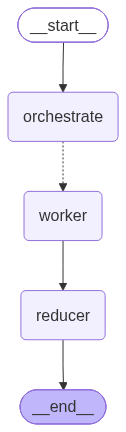

In [45]:
workflow = g.compile()
workflow

In [46]:
blog_input = "Write a blog post about OphioCordyceps fungus"
response = workflow.invoke({"topic": blog_input})

In [47]:
print(f"Blog\n{response['final']}")

Blog
# The Real-Life Zombie Fungus: Unveiling the Mysteries of Ophiocordyceps

## Introduction to Ophiocordyceps

Deep within the damp, shadowed canopies of tropical rain forests lies one of nature’s most chilling spectacles. Picture an ant, suddenly stripped of its free will, climbing mindlessly up a plant stem, locking its jaws into a leaf vein, and waiting to die. From the back of its lifeless husk, a slender, alien stalk erupts, bursting forth to release a cloud of microscopic spores. This is not the stuff of Hollywood fiction or a dystopian video game; it is the grim, captivating reality of *Ophiocordyceps*—the world's most infamous "zombie-maker" fungus. 

Long before humans ever conceptualized the undead, this parasitic organism was perfecting the art of mind control. Renowned for its terrifying yet brilliant life cycle, *Ophiocordyceps* has captured the imagination of scientists and nature enthusiasts alike. But beneath its horror-movie reputation lies a deeply fascinating orga